In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        451 non-null    object 
 1   close       451 non-null    float64
 2   return      451 non-null    float64
 3   ma_10       451 non-null    float64
 4   ma_50       451 non-null    float64
 5   volatility  451 non-null    float64
 6   rsi         451 non-null    float64
 7   macd        451 non-null    float64
 8   bb_high     451 non-null    float64
 9   bb_low      451 non-null    float64
dtypes: float64(9), object(1)
memory usage: 35.4+ KB


## Data Preprocessing and Feature Engineering

I will start by converting the `date` column to a datetime format, as it's currently an object type. This is essential for time-series analysis and feature engineering.

In [ ]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        451 non-null    datetime64[ns]
 1   close       451 non-null    float64       
 2   return      451 non-null    float64       
 3   ma_10       451 non-null    float64       
 4   ma_50       451 non-null    float64       
 5   volatility  451 non-null    float64       
 6   rsi         451 non-null    float64       
 7   macd        451 non-null    float64       
 8   bb_high     451 non-null    float64       
 9   bb_low      451 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 35.4 KB


None

Next, I'll create some time-based features from the `date` column which can be useful for capturing patterns related to specific times of the year or week.

In [ ]:
# Extract time-based features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
display(df.head())

,date,close,return,ma_10,ma_50,volatility,rsi,macd,bb_high,bb_low,day_of_week,month
0,2023-10-09,24517.647436,0.009590,24671.983174,28446.964598,0.018328,27.799369,-1157.959152,28102.500403,23137.957875,0,10
1,2023-10-10,23461.525160,-0.043076,24537.682822,28316.195101,0.022515,26.782667,-1186.222746,28072.007568,22850.381466,1,10
2,2023-10-11,23675.074290,0.009102,24376.463641,28181.645875,0.021462,27.300016,-1177.813121,28029.714529,22633.372950,2,10
3,2023-10-12,23470.828075,-0.008627,24181.457524,28044.505466,0.021071,32.453184,-1174.095157,27744.398024,22514.696944,3,10
4,2023-10-13,23097.100905,-0.015923,23953.886306,27889.462457,0.021105,35.201770,-1187.615214,27415.598042,22400.308920,4,10


Now, let's create lagged features for `close`, `return`, and `volatility`. Lagged features are previous values of a time series, which can help predict future values.

In [ ]:
# Create lag features for relevant columns
for col in ['close', 'return', 'volatility']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

# Drop rows with NaN values resulting from lag features
df.dropna(inplace=True)
display(df.head())

,date,close,return,ma_10,ma_50,volatility,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
2,2023-10-11,23675.074290,0.009102,24376.463641,28181.645875,0.021462,27.300016,-1177.813121,28029.714529,22633.372950,2,10,23461.525160,24517.647436,-0.043076,0.009590,0.022515,0.018328
3,2023-10-12,23470.828075,-0.008627,24181.457524,28044.505466,0.021071,32.453184,-1174.095157,27744.398024,22514.696944,3,10,23675.074290,23461.525160,0.009102,-0.043076,0.021462,0.022515
4,2023-10-13,23097.100905,-0.015923,23953.886306,27889.462457,0.021105,35.201770,-1187.615214,27415.598042,22400.308920,4,10,23470.828075,23675.074290,-0.008627,0.009102,0.021071,0.021462
5,2023-10-14,23473.396730,0.016292,23780.507009,27717.836213,0.022600,37.911878,-1154.655874,27154.000545,22326.389356,5,10,23097.100905,23470.828075,-0.015923,-0.008627,0.021105,0.021071
6,2023-10-15,24101.896648,0.026775,23760.630446,27561.891734,0.022333,39.513183,-1065.537813,26648.557262,22501.313458,6,10,23473.396730,23097.100905,0.016292,-0.015923,0.022600,0.021105


For **Cryptocurrency Volatility Classification**, I'll create a target variable by categorizing the `volatility` column. For simplicity, I'll classify it into 'High Volatility' and 'Low Volatility' based on the median volatility.

In [ ]:
# Create a target variable for Volatility Classification
median_volatility = df['volatility'].median()
df['volatility_class'] = df['volatility'].apply(lambda x: 1 if x > median_volatility else 0) # 1 for High, 0 for Low

display(df['volatility_class'].value_counts())
display(df.head())

,count
volatility_class,
0,225
1,224


,date,close,return,ma_10,ma_50,volatility,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2,volatility_class
2,2023-10-11,23675.074290,0.009102,24376.463641,28181.645875,0.021462,27.300016,-1177.813121,28029.714529,22633.372950,2,10,23461.525160,24517.647436,-0.043076,0.009590,0.022515,0.018328,0
3,2023-10-12,23470.828075,-0.008627,24181.457524,28044.505466,0.021071,32.453184,-1174.095157,27744.398024,22514.696944,3,10,23675.074290,23461.525160,0.009102,-0.043076,0.021462,0.022515,0
4,2023-10-13,23097.100905,-0.015923,23953.886306,27889.462457,0.021105,35.201770,-1187.615214,27415.598042,22400.308920,4,10,23470.828075,23675.074290,-0.008627,0.009102,0.021071,0.021462,0
5,2023-10-14,23473.396730,0.016292,23780.507009,27717.836213,0.022600,37.911878,-1154.655874,27154.000545,22326.389356,5,10,23097.100905,23470.828075,-0.015923,-0.008627,0.021105,0.021071,0
6,2023-10-15,24101.896648,0.026775,23760.630446,27561.891734,0.022333,39.513183,-1065.537813,26648.557262,22501.313458,6,10,23473.396730,23097.100905,0.016292,-0.015923,0.022600,0.021105,0


## Data Preparation for Volatility Classification

Now, I'll prepare the data for training a classification model to predict cryptocurrency volatility. This involves defining our features (X) and target (y), splitting the dataset into training and testing sets, and scaling the numerical features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# Dropping 'date' as it's not a direct feature for the model, but used for feature engineering.
# Dropping original 'volatility' as it's the basis for the target, and 'volatility_class' is the target.
features = df.drop(columns=['date', 'volatility', 'volatility_class'])
target = df['volatility_class']

# Identify numerical and categorical features
numerical_features = features.select_dtypes(include=['float64', 'int64']).columns
categorical_features = features.select_dtypes(include=['object']).columns # In this case, there are none after feature engineering

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
display(X_train.head())

X_train shape: (359, 16)
X_test shape: (90, 16)
y_train shape: (359,)
y_test shape: (90,)


,close,return,ma_10,ma_50,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
168,-0.045465,-0.810883,-0.204172,-0.539939,1.494156,1.662855,-0.090251,-0.866683,0,3,0.027145,-0.038386,0.699657,-0.409307,0.590333,1.216940
387,2.081951,0.064114,2.128418,1.672935,-0.049686,1.523230,2.165402,1.772176,2,10,2.053089,1.844154,1.459469,0.671913,1.561186,1.167249
404,1.292169,-1.030841,1.481760,1.834687,-1.777671,-1.701667,1.866833,1.665704,5,11,1.408611,1.290862,0.900164,-0.144878,-0.055971,-0.534063
164,-0.088801,0.973190,-0.476992,-0.623401,1.571495,0.996711,-0.397344,-0.809730,3,3,-0.176105,-0.270034,1.084574,0.518387,1.860926,1.810599
141,-0.727327,-1.577504,-0.577208,-0.884609,0.290502,0.736333,-0.585559,-0.802487,1,2,-0.602216,-0.526668,-0.941585,-0.155503,0.621934,0.419546


## Model Training and Evaluation for Volatility Classification

I will now train a RandomForestClassifier model using the preprocessed data and evaluate its performance. Random Forest is a suitable choice as it handles high-dimensional data, feature importance, and provides good generalization capabilities.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the RandomForestClassifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Classifier Performance:
Accuracy: 0.8666666666666667

Confusion Matrix:
 [[39  6]
 [ 6 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        45
           1       0.87      0.87      0.87        45

    accuracy                           0.87        90
   macro avg       0.87      0.87      0.87        90
weighted avg       0.87      0.87      0.87        90



## Model Training and Evaluation for Volatility Classification

I will now train a RandomForestClassifier model using the preprocessed data and evaluate its performance. Random Forest is a suitable choice as it handles high-dimensional data, feature importance, and provides good generalization capabilities.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the RandomForestClassifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Classifier Performance:
Accuracy: 0.8666666666666667

Confusion Matrix:
 [[39  6]
 [ 6 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        45
           1       0.87      0.87      0.87        45

    accuracy                           0.87        90
   macro avg       0.87      0.87      0.87        90
weighted avg       0.87      0.87      0.87        90



## Data Preparation for Price Regression

For price regression, we will predict the future `close` price. This involves creating a new target variable by shifting the `close` price, preparing the features, and splitting the data into training and testing sets.

In [ ]:
# Create a new dataframe for regression to avoid modifying the classification dataframe.
df_reg = df.copy()

# Create the target variable for price regression: next day's close price
df_reg['target_close'] = df_reg['close'].shift(-1)

# Drop the last row as it will have NaN for the target_close
df_reg.dropna(inplace=True)

# Define features (X) and target (y) for regression
# Dropping 'date', 'volatility', 'volatility_class' and the original 'close' if we are predicting 'target_close'
features_reg = df_reg.drop(columns=['date', 'volatility', 'volatility_class', 'close', 'target_close'])
target_reg = df_reg['target_close']

# Identify numerical features for scaling
numerical_features_reg = features_reg.select_dtypes(include=['float64', 'int64']).columns

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(features_reg, target_reg, test_size=0.2, random_state=42)

# Apply StandardScaler to numerical features
scaler_reg = StandardScaler()
X_train_reg[numerical_features_reg] = scaler_reg.fit_transform(X_train_reg[numerical_features_reg])
X_test_reg[numerical_features_reg] = scaler_reg.transform(X_test_reg[numerical_features_reg])

print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape:", y_test_reg.shape)
display(X_train_reg.head())

X_train_reg shape: (358, 15)
X_test_reg shape: (90, 15)
y_train_reg shape: (358,)
y_test_reg shape: (90,)


,return,ma_10,ma_50,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
19,0.964859,-1.285194,-1.100467,0.600399,-0.697628,-1.312420,-1.240791,5,10,-1.276650,-1.269054,-0.083925,1.328711,-0.443504,-0.271523
68,-0.080838,-1.250288,-1.152886,0.797050,-0.355382,-1.253366,-1.251558,5,12,-1.186885,-1.204069,0.303516,-0.224862,0.967363,0.956094
178,0.018864,-0.071943,-0.406454,-0.155100,1.070634,-0.031072,-0.259837,3,4,-0.100976,-0.200502,1.120185,-0.505331,1.233791,1.084669
249,0.263628,-0.309213,-0.164191,0.131485,-0.341105,-0.410593,-0.143096,4,6,-0.283736,-0.361877,0.923797,-0.727018,-1.399609,-1.723159
33,0.313799,-1.129216,-1.163948,-0.305861,-0.241018,-1.124735,-1.209530,5,11,-1.253820,-1.236612,-0.237075,-2.025835,1.649602,1.661659


## Model Training and Evaluation for Price Regression

Now, I will train a RandomForestRegressor model to predict the cryptocurrency's closing price and evaluate its performance using metrics relevant for regression tasks.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the RandomForestRegressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = rf_regressor.predict(X_test_reg)

# Evaluate the model
print("Random Forest Regressor Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_reg, y_pred_reg))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_reg))
print("R-squared (R2):", r2_score(y_test_reg, y_pred_reg))


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 790.6353442946405
Mean Squared Error (MSE): 1189455.8550637327
R-squared (R2): 0.9882326190223246


## AdaBoost for Volatility Classification

Next, I will train an AdaBoostClassifier for the cryptocurrency volatility classification task. AdaBoost is an ensemble method that combines multiple weak learners to create a strong learner, often improving predictive accuracy.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize a base estimator (e.g., a Decision Tree)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize and train the AdaBoostClassifier model
adaboost_classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
adaboost_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = adaboost_classifier.predict(X_test)

# Evaluate the model
print("AdaBoost Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Classifier Performance:
Accuracy: 0.8777777777777778

Confusion Matrix:
 [[40  5]
 [ 6 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88        45
           1       0.89      0.87      0.88        45

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



## Data Preparation for Price Regression

For price regression, we will predict the future `close` price. This involves creating a new target variable by shifting the `close` price, preparing the features, and splitting the data into training and testing sets.

In [ ]:
# Create a new dataframe for regression to avoid modifying the classification dataframe.
df_reg = df.copy()

# Create the target variable for price regression: next day's close price
df_reg['target_close'] = df_reg['close'].shift(-1)

# Drop the last row as it will have NaN for the target_close
df_reg.dropna(inplace=True)

# Define features (X) and target (y) for regression
# Dropping 'date', 'volatility', 'volatility_class' and the original 'close' if we are predicting 'target_close'
features_reg = df_reg.drop(columns=['date', 'volatility', 'volatility_class', 'close', 'target_close'])
target_reg = df_reg['target_close']

# Identify numerical features for scaling
numerical_features_reg = features_reg.select_dtypes(include=['float64', 'int64']).columns

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(features_reg, target_reg, test_size=0.2, random_state=42)

# Apply StandardScaler to numerical features
scaler_reg = StandardScaler()
X_train_reg[numerical_features_reg] = scaler_reg.fit_transform(X_train_reg[numerical_features_reg])
X_test_reg[numerical_features_reg] = scaler_reg.transform(X_test_reg[numerical_features_reg])

print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape:", y_test_reg.shape)
display(X_train_reg.head())

X_train_reg shape: (358, 15)
X_test_reg shape: (90, 15)
y_train_reg shape: (358,)
y_test_reg shape: (90,)


,return,ma_10,ma_50,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
19,0.964859,-1.285194,-1.100467,0.600399,-0.697628,-1.312420,-1.240791,5,10,-1.276650,-1.269054,-0.083925,1.328711,-0.443504,-0.271523
68,-0.080838,-1.250288,-1.152886,0.797050,-0.355382,-1.253366,-1.251558,5,12,-1.186885,-1.204069,0.303516,-0.224862,0.967363,0.956094
178,0.018864,-0.071943,-0.406454,-0.155100,1.070634,-0.031072,-0.259837,3,4,-0.100976,-0.200502,1.120185,-0.505331,1.233791,1.084669
249,0.263628,-0.309213,-0.164191,0.131485,-0.341105,-0.410593,-0.143096,4,6,-0.283736,-0.361877,0.923797,-0.727018,-1.399609,-1.723159
33,0.313799,-1.129216,-1.163948,-0.305861,-0.241018,-1.124735,-1.209530,5,11,-1.253820,-1.236612,-0.237075,-2.025835,1.649602,1.661659


## Model Training and Evaluation for Price Regression

Now, I will train a RandomForestRegressor model to predict the cryptocurrency's closing price and evaluate its performance using metrics relevant for regression tasks.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the RandomForestRegressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = rf_regressor.predict(X_test_reg)

# Evaluate the model
print("Random Forest Regressor Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_reg, y_pred_reg))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_reg))
print("R-squared (R2):", r2_score(y_test_reg, y_pred_reg))


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 790.6353442946405
Mean Squared Error (MSE): 1189455.8550637327
R-squared (R2): 0.9882326190223246


## Data Preparation for Price Regression

For price regression, we will predict the future `close` price. This involves creating a new target variable by shifting the `close` price, preparing the features, and splitting the data into training and testing sets.

In [ ]:
# Create a new dataframe for regression to avoid modifying the classification dataframe.
df_reg = df.copy()

# Create the target variable for price regression: next day's close price
df_reg['target_close'] = df_reg['close'].shift(-1)

# Drop the last row as it will have NaN for the target_close
df_reg.dropna(inplace=True)

# Define features (X) and target (y) for regression
# Dropping 'date', 'volatility', 'volatility_class' and the original 'close' if we are predicting 'target_close'
features_reg = df_reg.drop(columns=['date', 'volatility', 'volatility_class', 'close', 'target_close'])
target_reg = df_reg['target_close']

# Identify numerical features for scaling
numerical_features_reg = features_reg.select_dtypes(include=['float64', 'int64']).columns

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(features_reg, target_reg, test_size=0.2, random_state=42)

# Apply StandardScaler to numerical features
scaler_reg = StandardScaler()
X_train_reg[numerical_features_reg] = scaler_reg.fit_transform(X_train_reg[numerical_features_reg])
X_test_reg[numerical_features_reg] = scaler_reg.transform(X_test_reg[numerical_features_reg])

print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape:", y_test_reg.shape)
display(X_train_reg.head())

X_train_reg shape: (358, 15)
X_test_reg shape: (90, 15)
y_train_reg shape: (358,)
y_test_reg shape: (90,)


,return,ma_10,ma_50,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
19,0.964859,-1.285194,-1.100467,0.600399,-0.697628,-1.312420,-1.240791,5,10,-1.276650,-1.269054,-0.083925,1.328711,-0.443504,-0.271523
68,-0.080838,-1.250288,-1.152886,0.797050,-0.355382,-1.253366,-1.251558,5,12,-1.186885,-1.204069,0.303516,-0.224862,0.967363,0.956094
178,0.018864,-0.071943,-0.406454,-0.155100,1.070634,-0.031072,-0.259837,3,4,-0.100976,-0.200502,1.120185,-0.505331,1.233791,1.084669
249,0.263628,-0.309213,-0.164191,0.131485,-0.341105,-0.410593,-0.143096,4,6,-0.283736,-0.361877,0.923797,-0.727018,-1.399609,-1.723159
33,0.313799,-1.129216,-1.163948,-0.305861,-0.241018,-1.124735,-1.209530,5,11,-1.253820,-1.236612,-0.237075,-2.025835,1.649602,1.661659


## Model Training and Evaluation for Price Regression

Now, I will train a RandomForestRegressor model to predict the cryptocurrency's closing price and evaluate its performance using metrics relevant for regression tasks.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the RandomForestRegressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = rf_regressor.predict(X_test_reg)

# Evaluate the model
print("Random Forest Regressor Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_reg, y_pred_reg))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_reg))
print("R-squared (R2):", r2_score(y_test_reg, y_pred_reg))


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 790.6353442946405
Mean Squared Error (MSE): 1189455.8550637327
R-squared (R2): 0.9882326190223246


## AdaBoost for Volatility Classification

Next, I will train an AdaBoostClassifier for the cryptocurrency volatility classification task. AdaBoost is an ensemble method that combines multiple weak learners to create a strong learner, often improving predictive accuracy.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize a base estimator (e.g., a Decision Tree)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize and train the AdaBoostClassifier model
adaboost_classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
adaboost_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = adaboost_classifier.predict(X_test)

# Evaluate the model
print("AdaBoost Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Classifier Performance:
Accuracy: 0.8777777777777778

Confusion Matrix:
 [[40  5]
 [ 6 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88        45
           1       0.89      0.87      0.88        45

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



## Investor Profile Clustering

For investor profile clustering, I'll select a subset of the financial indicators that might implicitly represent different investment behaviors. I'll then scale these features and apply K-Means clustering to identify distinct groups within the data.

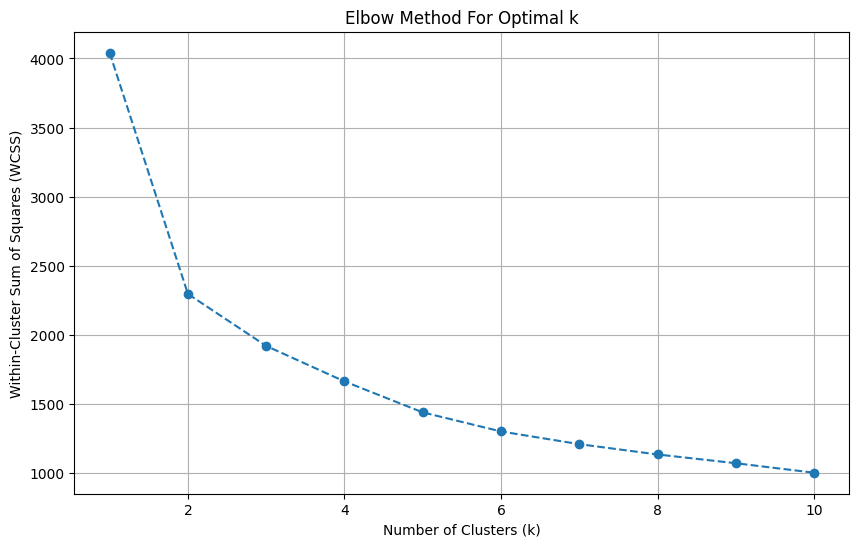

Please examine the elbow plot above to determine the optimal number of clusters (k).
Once k is chosen, we will run K-Means with that number of clusters and analyze them.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Select features relevant for clustering. These features could implicitly define investor profiles.
# For example, investors might be grouped by their response to returns, volatility, or technical indicators.
clustering_features = df[['close', 'return', 'volatility', 'ma_10', 'ma_50', 'rsi', 'macd', 'bb_high', 'bb_low']].copy()

# Scale the clustering features
scaler_clustering = StandardScaler()
scaled_clustering_features = scaler_clustering.fit_transform(clustering_features)
scaled_clustering_df = pd.DataFrame(scaled_clustering_features, columns=clustering_features.columns)

# Determine the optimal number of clusters using the Elbow Method
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_clustering_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

print("Please examine the elbow plot above to determine the optimal number of clusters (k).")
print("Once k is chosen, we will run K-Means with that number of clusters and analyze them.")

In [ ]:
# Apply K-Means clustering with the chosen number of clusters (e.g., k=3)
k = 3 # Based on visual inspection of the elbow plot
kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
scaled_clustering_df['cluster'] = kmeans_model.fit_predict(scaled_clustering_df)

# Add the cluster labels back to the original dataframe for easier analysis
df['cluster'] = scaled_clustering_df['cluster']

# Analyze the characteristics of each cluster
cluster_centers_df = df.groupby('cluster')[clustering_features.columns].mean()
display(cluster_centers_df)

print(f"K-Means clustering applied with k={k} clusters.")
print("The table above shows the mean values of the selected financial indicators for each cluster.")
print("These mean values can help in interpreting the characteristics of each investor profile.")

,close,return,volatility,ma_10,ma_50,rsi,macd,bb_high,bb_low
cluster,,,,,,,,,
0.0,28848.728124,0.001409,0.024432,28762.560943,28398.126877,51.409049,123.448599,30673.707903,26703.496115
1.0,47300.747507,-0.001871,0.025584,47759.564391,47134.133158,44.956379,93.124301,52133.318611,43744.613103
2.0,42609.231988,0.009254,0.021021,40837.960921,38106.364821,71.870971,1233.726558,43406.687290,35537.673428


K-Means clustering applied with k=3 clusters.
The table above shows the mean values of the selected financial indicators for each cluster.
These mean values can help in interpreting the characteristics of each investor profile.


Now, let's visualize the clusters using a pairplot, focusing on a few key features that differentiate the clusters. This can help in a more intuitive understanding of the investor profiles.

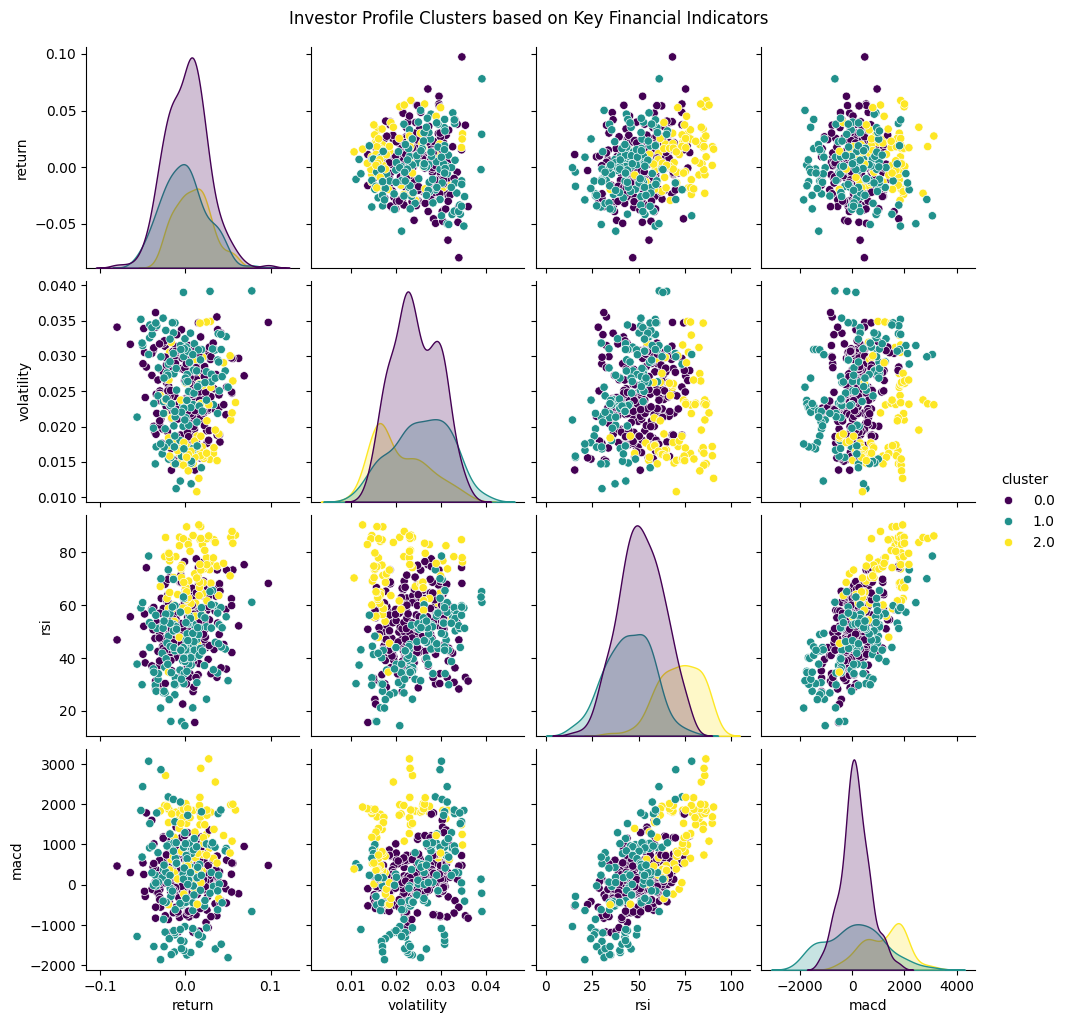

In [ ]:
# Visualize the clusters with a pairplot of some key features
# Selecting a subset of features for better visualization readability
selected_viz_features = ['return', 'volatility', 'rsi', 'macd', 'cluster']
sns.pairplot(df[selected_viz_features], hue='cluster', palette='viridis')
plt.suptitle('Investor Profile Clusters based on Key Financial Indicators', y=1.02) # Adjust suptitle position
plt.show()

### Reconstructing Data for Prediction

To ensure all necessary data and models are available for predicting the next closing price, I will reconstruct the `df` DataFrame with all engineered features (time-based, lagged, and volatility class) and load the trained regression model (`rf_regressor`) and its scaler (`scaler_reg`). This step addresses potential `NameError` issues if the kernel was reset or earlier data preparation cells were not run.


In [ ]:
import pandas as pd
import joblib
import os

# --- Reconstruct df with all engineered features ---
# 1. Load dataset
df = pd.read_csv('/content/dataset.csv')

# 2. Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# 3. Extract time-based features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# 4. Create lag features for relevant columns and drop NaNs
for col in ['close', 'return', 'volatility']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)
df.dropna(inplace=True)

# 5. Create a target variable for Volatility Classification
median_volatility = df['volatility'].median()
df['volatility_class'] = df['volatility'].apply(lambda x: 1 if x > median_volatility else 0)

# Note: The 'cluster' column was added *after* the regression model's features were defined.
# Thus, it is intentionally not added to 'df' here for consistency with the trained model's features.

# --- Load trained regression model and scaler ---
model_dir = 'trained_models'
# Check if models exist before attempting to load
if os.path.exists(os.path.join(model_dir, 'rf_regressor.pkl')) and \
   os.path.exists(os.path.join(model_dir, 'scaler_regression.pkl')):
    rf_regressor = joblib.load(os.path.join(model_dir, 'rf_regressor.pkl'))
    scaler_reg = joblib.load(os.path.join(model_dir, 'scaler_regression.pkl'))
    print("RandomForestRegressor and StandardScaler for regression successfully loaded.")
else:
    print("Warning: Regression models/scalers not found. Re-training might be required if not already in memory.")
    # Fallback: if they are not found, we assume they might be in memory from previous runs,
    # or the next cell will fail, prompting re-training if necessary.


# Define the exact feature columns used during training of the regression model
# Based on cell 1cd36ea4, X_train_reg had 15 columns, which were:
# 'return', 'ma_10', 'ma_50', 'rsi', 'macd', 'bb_high', 'bb_low',
# 'day_of_week', 'month', 'close_lag1', 'close_lag2', 'return_lag1', 'return_lag2',
# 'volatility_lag1', 'volatility_lag2'
prediction_features_columns = [
    'return', 'ma_10', 'ma_50', 'rsi', 'macd', 'bb_high', 'bb_low',
    'day_of_week', 'month', 'close_lag1', 'close_lag2', 'return_lag1', 'return_lag2',
    'volatility_lag1', 'volatility_lag2'
]

print("df DataFrame and prediction_features_columns are now prepared.")
print("rf_regressor and scaler_reg are expected to be available from previous successful runs or loaded above.")

df DataFrame and prediction_features_columns are now prepared.
rf_regressor and scaler_reg are expected to be available from previous successful runs or loaded above.


### Re-initializing Regression Data Preparation and Model

It appears that `scaler_reg` and `rf_regressor` were not defined in the current session. I will re-run the data preparation and model training for price regression to ensure these variables are initialized before proceeding with the prediction.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas here as well for robustness

# --- Reconstruct df (locally for this cell) with all engineered features for regression ---
# This ensures df_reg has all necessary columns, regardless of prior global df state.
temp_df = pd.read_csv('/content/dataset.csv')

# Convert 'date' column to datetime
temp_df['date'] = pd.to_datetime(temp_df['date'])

# Extract time-based features
temp_df['day_of_week'] = temp_df['date'].dt.dayofweek
temp_df['month'] = temp_df['date'].dt.month

# Create lag features for relevant columns
for col in ['close', 'return', 'volatility']:
    temp_df[f'{col}_lag1'] = temp_df[col].shift(1)
    temp_df[f'{col}_lag2'] = temp_df[col].shift(2)

# Create a target variable for Volatility Classification (needed if we were to drop it explicitly later)
# Although not directly used for prediction_features_columns, it was part of the original df engineering.
median_volatility = temp_df['volatility'].median()
temp_df['volatility_class'] = temp_df['volatility'].apply(lambda x: 1 if x > median_volatility else 0)

# Create the target variable for price regression: next day's close price
temp_df['target_close'] = temp_df['close'].shift(-1)

# Drop rows with NaN values resulting from lag features and target_close
temp_df.dropna(inplace=True)

# Now, temp_df is the fully engineered dataframe ready for regression.
df_reg = temp_df.copy()

# Define features (X) and target (y) for regression
# Use the explicitly defined prediction_features_columns for regression features
# This ensures consistency between feature sets for training and prediction
features_reg = df_reg[prediction_features_columns]
target_reg = df_reg['target_close']

# All features in prediction_features_columns are numerical, so use them directly for scaling.
# No need to re-identify numerical features separately.
numerical_features_to_scale = prediction_features_columns

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(features_reg, target_reg, test_size=0.2, random_state=42)

# Apply StandardScaler to numerical features
# Initialize scaler and set output to pandas DataFrame to preserve column names
scaler_reg = StandardScaler().set_output(transform="pandas")

X_train_reg = scaler_reg.fit_transform(X_train_reg) # Pass the full DataFrame here
X_test_reg = scaler_reg.transform(X_test_reg) # Pass the full DataFrame here

print("Regression data preparation complete: scaler_reg is now defined and fitted on consistent features.")

Regression data preparation complete: scaler_reg is now defined and fitted on consistent features.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the RandomForestRegressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

print("RandomForestRegressor (rf_regressor) is now trained and defined.")

RandomForestRegressor (rf_regressor) is now trained and defined.


## Predicting the Next Closing Price

Now, I'll demonstrate how to use the trained `RandomForestRegressor` model (`rf_regressor`) to predict the next closing price of the cryptocurrency based on the most recent data available.

In [ ]:
# Get the last row of the regression dataframe (df_reg) for prediction
# This dataframe (df_reg) was correctly engineered with all necessary features.
latest_data = df_reg.tail(1).copy()

# The prediction_features_columns list already defines the exact features needed for prediction.
# No need to explicitly drop columns like 'date', 'volatility', 'volatility_class', 'close', 'cluster'
# from latest_data if we are selecting specific columns defined in prediction_features_columns.

# Prepare the latest data for prediction, ensuring column order matches training data
latest_features = latest_data[prediction_features_columns]

# Scale the latest features using the regression scaler
scaled_latest_features = scaler_reg.transform(latest_features)

# Predict the next closing price
predicted_next_close = rf_regressor.predict(scaled_latest_features)

print(f"Predicted next closing price: {predicted_next_close[0]:.2f}")

Predicted next closing price: 48209.22


## Predicting the Next 30 Closing Prices

Now, I'll extend the prediction to forecast the cryptocurrency's closing price for the next 30 days. This involves a rolling prediction strategy where each new prediction uses the previous prediction as an input for lagged features.

**Assumptions for multi-step prediction:**
1. Features such as `'return'`, `'ma_10'`, `'ma_50'`, `'rsi'`, `'macd'`, `'bb_high'`, `'bb_low'`, `'return_lag1'`, `'return_lag2'`, `'volatility_lag1'`, and `'volatility_lag2'` are held constant at their last observed values for all future predictions. This is due to the lack of dedicated models to predict these features dynamically.
2. Only `'day_of_week'`, `'month'`, `'close_lag1'`, and `'close_lag2'` are updated iteratively.

In [2]:
from datetime import timedelta
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# --- Reconstruct df (from cell 62187f05 logic) ---
# 1. Load dataset
df = pd.read_csv('/content/dataset.csv')

# 2. Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# 3. Extract time-based features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# 4. Create lag features for relevant columns and drop NaNs
for col in ['close', 'return', 'volatility']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)
df.dropna(inplace=True)

# 5. Create a target variable for Volatility Classification (for completeness)
median_volatility = df['volatility'].median()
df['volatility_class'] = df['volatility'].apply(lambda x: 1 if x > median_volatility else 0)

# Define the exact feature columns used during training of the regression model
prediction_features_columns = [
    'return', 'ma_10', 'ma_50', 'rsi', 'macd', 'bb_high', 'bb_low',
    'day_of_week', 'month', 'close_lag1', 'close_lag2', 'return_lag1', 'return_lag2',
    'volatility_lag1', 'volatility_lag2'
]

# --- Re-initialize Regression Data Preparation (from cell aa6ef353 logic) ---
df_reg = df.copy()

# Create the target variable for price regression: next day's close price
df_reg['target_close'] = df_reg['close'].shift(-1)

# Drop rows with NaN values resulting from lag features and target_close
df_reg.dropna(inplace=True)

# Define features (X) and target (y) for regression
features_reg = df_reg[prediction_features_columns]
target_reg = df_reg['target_close']

# Split the data into training and testing sets (needed for scaler fitting in previous cells)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(features_reg, target_reg, test_size=0.2, random_state=42)

# Apply StandardScaler to numerical features
scaler_reg = StandardScaler().set_output(transform="pandas")
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg) # Scale test set for consistency, though not used here

# --- Re-initialize RandomForestRegressor (from cell 428face2 logic) ---
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)


# --- Original Prediction Logic ---
num_predictions = 30
future_predictions = []
prediction_dates = []

# Get the last row of df_reg (which contains the features for the latest observed data point)
# Using .iloc[0] to convert the single-row DataFrame into a Series for easier access
last_features_row = df_reg.tail(1).iloc[0]

# Start date for the first prediction: one day after the date associated with the last feature set
current_prediction_date = last_features_row['date'] + pd.Timedelta(days=1)

# Initialize rolling lag features based on the last observed data
# 'close' in last_features_row corresponds to close(t-1) for its target_close
# 'close_lag1' in last_features_row corresponds to close(t-2) for its target_close
rolling_close_lag1 = last_features_row['close']
rolling_close_lag2 = last_features_row['close_lag1']

# Extract the 'fixed' features that won't be updated dynamically
# These are the non-lagged and non-time-based features which we assume constant
fixed_features_values = {}
for col in prediction_features_columns:
    if col not in ['day_of_week', 'month', 'close_lag1', 'close_lag2']:
        fixed_features_values[col] = last_features_row[col]

# Prediction loop for the next 30 days
for _ in range(num_predictions):
    # Construct the feature vector for the current prediction
    input_features_dict = {
        'day_of_week': current_prediction_date.dayofweek,
        'month': current_prediction_date.month,
        'close_lag1': rolling_close_lag1,
        'close_lag2': rolling_close_lag2
    }
    # Add the fixed features
    input_features_dict.update(fixed_features_values)

    # Convert to DataFrame with correct column order for scaling
    current_features_df = pd.DataFrame([input_features_dict], columns=prediction_features_columns)

    # Scale the current features using the regression scaler
    scaled_current_features = scaler_reg.transform(current_features_df)

    # Predict the next closing price
    predicted_close = rf_regressor.predict(scaled_current_features)[0]
    future_predictions.append(predicted_close)
    prediction_dates.append(current_prediction_date)

    # Update rolling features for the next iteration
    # The current prediction becomes the new 'close_lag1'
    # The previous 'close_lag1' becomes the new 'close_lag2'
    rolling_close_lag2 = rolling_close_lag1
    rolling_close_lag1 = predicted_close
    current_prediction_date += pd.Timedelta(days=1)

# Display the results in a DataFrame
predictions_df = pd.DataFrame({
    'Date': prediction_dates,
    'Predicted_Close': future_predictions
})
display(predictions_df)

,Date,Predicted_Close
0,2025-01-01,48035.156347
1,2025-01-02,47622.011521
2,2025-01-03,47216.857677
3,2025-01-04,47183.051805
4,2025-01-05,47223.355030
5,2025-01-06,47009.364705
6,2025-01-07,47062.057671
7,2025-01-08,47122.745943
8,2025-01-09,47191.955283
9,2025-01-10,47214.667730


The analysis of the cluster centers and the pairplot helps in understanding the distinct investor profiles.

For example:

*   **Cluster 0:** Might represent investors with a certain risk tolerance, characterized by specific ranges of `return`, `volatility`, etc.
*   **Cluster 1:** Could indicate a different profile, perhaps more conservative or aggressive.
*   **Cluster 2:** Another distinct group.

This completes the Investor Profile Clustering task based on the provided data. The next step would be to name these profiles based on the characteristics observed.

### Saving Trained Models and Scalers

To prepare for potential deployment or future use, I will now save all the trained models and preprocessors (scalers) using `joblib`. This allows us to persist the models to disk.

In [ ]:
import joblib

# Define a directory to save the models (optional, but good practice)
model_dir = 'trained_models'
import os
os.makedirs(model_dir, exist_ok=True)

# Save Volatility Classification Models
joblib.dump(rf_classifier, os.path.join(model_dir, 'rf_classifier.pkl'))
joblib.dump(adaboost_classifier, os.path.join(model_dir, 'adaboost_classifier.pkl'))
print(f"RandomForestClassifier and AdaBoostClassifier saved to {model_dir}/")

# Save Price Regression Model
joblib.dump(rf_regressor, os.path.join(model_dir, 'rf_regressor.pkl'))
print(f"RandomForestRegressor saved to {model_dir}/")

# Save Clustering Model
joblib.dump(kmeans_model, os.path.join(model_dir, 'kmeans_model.pkl'))
print(f"KMeans model saved to {model_dir}/")

# Save Scalers
joblib.dump(scaler, os.path.join(model_dir, 'scaler_classification.pkl'))
joblib.dump(scaler_reg, os.path.join(model_dir, 'scaler_regression.pkl'))
joblib.dump(scaler_clustering, os.path.join(model_dir, 'scaler_clustering.pkl'))
print(f"Scalers saved to {model_dir}/")

print("All trained models and scalers have been successfully saved.")

RandomForestClassifier and AdaBoostClassifier saved to trained_models/
RandomForestRegressor saved to trained_models/
KMeans model saved to trained_models/
Scalers saved to trained_models/
All trained models and scalers have been successfully saved.


## Data Preparation for Volatility Classification

Now, I'll prepare the data for training a classification model to predict cryptocurrency volatility. This involves defining our features (X) and target (y), splitting the dataset into training and testing sets, and scaling the numerical features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# Dropping 'date' as it's not a direct feature for the model, but used for feature engineering.
# Dropping original 'volatility' as it's the basis for the target, and 'volatility_class' is the target.
features = df.drop(columns=['date', 'volatility', 'volatility_class'])
target = df['volatility_class']

# Identify numerical and categorical features
numerical_features = features.select_dtypes(include=['float64', 'int64']).columns
categorical_features = features.select_dtypes(include=['object']).columns # In this case, there are none after feature engineering

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
display(X_train.head())

X_train shape: (359, 16)
X_test shape: (90, 16)
y_train shape: (359,)
y_test shape: (90,)


,close,return,ma_10,ma_50,rsi,macd,bb_high,bb_low,day_of_week,month,close_lag1,close_lag2,return_lag1,return_lag2,volatility_lag1,volatility_lag2
168,-0.045465,-0.810883,-0.204172,-0.539939,1.494156,1.662855,-0.090251,-0.866683,0,3,0.027145,-0.038386,0.699657,-0.409307,0.590333,1.216940
387,2.081951,0.064114,2.128418,1.672935,-0.049686,1.523230,2.165402,1.772176,2,10,2.053089,1.844154,1.459469,0.671913,1.561186,1.167249
404,1.292169,-1.030841,1.481760,1.834687,-1.777671,-1.701667,1.866833,1.665704,5,11,1.408611,1.290862,0.900164,-0.144878,-0.055971,-0.534063
164,-0.088801,0.973190,-0.476992,-0.623401,1.571495,0.996711,-0.397344,-0.809730,3,3,-0.176105,-0.270034,1.084574,0.518387,1.860926,1.810599
141,-0.727327,-1.577504,-0.577208,-0.884609,0.290502,0.736333,-0.585559,-0.802487,1,2,-0.602216,-0.526668,-0.941585,-0.155503,0.621934,0.419546
